# Camada Gold — Risco de Alerta "Don't Go"
### Pergunta que eu quero responder
Quais equipamentos têm maior risco de gerar um alerta crítico ("don't go") nas
próximas horas, dado o padrão atual de operação — e dá pra enxergar um sinal de
comportamento anômalo que antecede esse alerta?

Antes de chegar até aqui, rodei uma EDA em cima da Silver e descobri três coisas que
mudaram completamente como eu ia montar esse notebook:

1. **70% dos registros de `is_dont_go=1` são o mesmo alarme "chacoalhando"** — um
   sensor de temperatura de freio, por exemplo, fica alternando active/inactive
   várias vezes em minutos porque o valor está bem em cima do limiar. Se eu treinar
   em cima do evento bruto, o modelo aprende a prever esse ruído de sensor, não risco
   real. Por isso, antes de qualquer coisa, eu consolido esses alertas em "episódios".
2. **O join entre a telemetria e o catálogo de regras de negócio não funciona** — são
   escalas de criticidade diferentes (o catálogo usa "alto"/"muito alto", a
   telemetria usa "informacional"/"não crítico"/"crítico"). Por isso não uso esse
   cruzamento em lugar nenhum aqui, só a coluna `is_dont_go` que já vem pronta.
3. **Tem um outlier de ingestão real**: um equipamento (`PE3798`) gerou 1,3 milhão de
   eventos em um único dia, isso é claramente um problema de sensor/reprocessamento,
   não uso real da máquina. Preciso limitar (winsorizar) a feature de contagem de
   eventos pra esse outlier não estragar a escala pros outros equipamentos.

## 0. Carregando a Silver

In [0]:
%pip install --upgrade shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.7/15.7 MB 135.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
%pip install "numpy<2.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.9/13.9 MB 122.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.6
    Uninstalling numpy-2.4.6:
      Successfully uninstalled numpy-2.4.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
dbutils.library.restartPython()

In [0]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

df_apontamentos = spark.table("`estudo-guiado`.vale_silver.apontamentos")
df_telemetria    = spark.table("`estudo-guiado`.vale_silver.telemetria")

print(f"Apontamentos: {df_apontamentos.count():,} linhas")
print(f"Telemetria:   {df_telemetria.count():,} linhas")

Apontamentos: 377,907 linhas
Telemetria:   37,164,054 linhas


## 1. Consolidando os alertas em episódios (debounce)

A ideia é simples: se o mesmo alarme, no mesmo equipamento, disparar de novo em menos
de 30 minutos, não conto como um novo evento de risco — é o mesmo problema ainda
"chacoalhando". Só a primeira ocorrência dentro dessa janela vira um episódio.

O ponto que eu preciso tomar cuidado aqui: pra calcular "quanto tempo desde o último
alerta desse mesmo alarme", eu tenho que olhar **só entre os alertas**, e não entre
qualquer linha da telemetria. Se eu comparar com a linha anterior da telemetria em
geral (que na imensa maioria das vezes não é um alerta), a conta de "tempo desde o
último alerta" sai errada — porque a maior parte dos registros no meio nem é alerta.
Por isso eu separo os alertas primeiro, calculo o debounce só entre eles, e depois
junto essa informação de volta na base completa.

In [0]:
JANELA_DEBOUNCE_MINUTOS = 30

# Separo só os alertas — é entre eles que a distância no tempo importa
df_alertas_brutos = df_telemetria.filter(F.col("is_dont_go") == 1)

janela_tag_alarme = Window.partitionBy("tag", "alarme").orderBy("data_evento")

df_alertas_com_episodio = (
    df_alertas_brutos
    .withColumn("data_evento_anterior_mesmo_alarme", F.lag("data_evento").over(janela_tag_alarme))
    .withColumn(
        "minutos_desde_mesmo_alarme",
        (F.col("data_evento").cast("long") - F.col("data_evento_anterior_mesmo_alarme").cast("long")) / 60.0
    )
    .withColumn(
        "inicio_novo_episodio",
        F.when(
            F.col("minutos_desde_mesmo_alarme").isNull() | (F.col("minutos_desde_mesmo_alarme") > JANELA_DEBOUNCE_MINUTOS),
            1
        ).otherwise(0)
    )
    .select("id_eventos_telemetria", "inicio_novo_episodio")
)

# Agora junto essa flag de volta com a telemetria inteira. Quem não é alerta fica com 0.
df_telemetria_episodios = (
    df_telemetria
    .join(df_alertas_com_episodio, on="id_eventos_telemetria", how="left")
    .fillna(0, subset=["inicio_novo_episodio"])
)

qtd_eventos_brutos = df_telemetria_episodios.filter(F.col("is_dont_go") == 1).count()
qtd_episodios = df_telemetria_episodios.filter(F.col("inicio_novo_episodio") == 1).count()
print(f"Eventos brutos de is_dont_go=1: {qtd_eventos_brutos:,}")
print(f"Episódios (após debounce de {JANELA_DEBOUNCE_MINUTOS}min): {qtd_episodios:,} "
      f"({qtd_episodios/qtd_eventos_brutos:.1%} do total bruto)")
print("Esse número precisa bater com o que achei na EDA (~29,5%) — se vier diferente,")
print("alguma coisa mudou na base entre a EDA e agora e vale investigar antes de seguir.")

Eventos brutos de is_dont_go=1: 19,962
Episódios (após debounce de 30min): 5,890 (29.5% do total bruto)
Esse número precisa bater com o que achei na EDA (~29,5%) — se vier diferente,
alguma coisa mudou na base entre a EDA e agora e vale investigar antes de seguir.


## 2. Montando as features — agrupando por equipamento e hora

A telemetria tem um evento por vez, o que é granularidade demais pra prever risco nas
próximas horas. Agrupo tudo por `tag` (equipamento) + hora, e a partir daí construo
as features de histórico recente.

In [0]:
df_telemetria_hora = (
    df_telemetria_episodios
    .withColumn("data_hora", F.date_trunc("hour", F.col("data_evento")))
    .groupBy("tag", "data_hora")
    .agg(
        F.count("*").alias("qtd_eventos_hora"),
        F.sum("inicio_novo_episodio").alias("qtd_episodios_hora"),
        F.avg("valor").alias("valor_medio_hora"),
        F.stddev("valor").alias("valor_desvio_hora"),
        F.sum(F.when(F.col("criticidade") == "critico", 1).otherwise(0)).alias("qtd_criticos_hora"),
    )
    .withColumn("hora_do_dia", F.hour("data_hora"))
    .withColumn("dia_semana", F.dayofweek("data_hora"))
    .withColumn(
        "turno",
        F.when((F.col("hora_do_dia") >= 6) & (F.col("hora_do_dia") < 14), "manha")
         .when((F.col("hora_do_dia") >= 14) & (F.col("hora_do_dia") < 22), "tarde")
         .otherwise("noite")
    )
    .withColumn("timestamp_unix", F.unix_timestamp("data_hora"))
)

print(f"Linhas após agregar por tag+hora: {df_telemetria_hora.count():,}")

Linhas após agregar por tag+hora: 107,391


### 2.1 Histórico recente — quantos episódios esse equipamento já teve nas últimas 24h
Essa é provavelmente a feature mais importante: um equipamento que já vem dando
sinal de problema tem mais chance de dar problema de novo.

In [0]:
janela_24h_passado = (
    Window.partitionBy("tag")
    .orderBy("timestamp_unix")
    .rangeBetween(-24 * 3600, -1)
)

df_telemetria_hora = df_telemetria_hora.withColumn(
    "qtd_episodios_ultimas_24h", F.coalesce(F.sum("qtd_episodios_hora").over(janela_24h_passado), F.lit(0))
).withColumn(
    "qtd_eventos_ultimas_24h", F.coalesce(F.sum("qtd_eventos_hora").over(janela_24h_passado), F.lit(0))
)

### 2.2 O alvo — vai ter episódio nas próximas horas?
Crio duas versões: 4h (minha janela principal, baseada na mediana real de tempo
entre episódios que achei na EDA — 1,84h, o que sustenta uma janela de poucas horas)
e 8h (pra testar sensibilidade, como o próprio Estudo Guiado sugere).

In [0]:
def criar_alvo(df, horas_janela):
    janela_futuro = (
        Window.partitionBy("tag")
        .orderBy("timestamp_unix")
        .rangeBetween(1, horas_janela * 3600)
    )
    nome_coluna = f"target_dont_go_proximas_{horas_janela}h"
    return df.withColumn(
        nome_coluna,
        F.when(F.coalesce(F.max("qtd_episodios_hora").over(janela_futuro), F.lit(0)) > 0, 1).otherwise(0)
    )

df_telemetria_hora = criar_alvo(df_telemetria_hora, 4)
df_telemetria_hora = criar_alvo(df_telemetria_hora, 8)

for h in [4, 8]:
    coluna = f"target_dont_go_proximas_{h}h"
    qtd_pos = df_telemetria_hora.filter(F.col(coluna) == 1).count()
    qtd_tot = df_telemetria_hora.count()
    print(f"Janela {h}h — positivos: {qtd_pos:,} / {qtd_tot:,} ({qtd_pos/qtd_tot:.3%})")

Janela 4h — positivos: 12,463 / 107,391 (11.605%)
Janela 8h — positivos: 18,835 / 107,391 (17.539%)


## 3. Juntando informação dos Apontamentos e codificando as categorias

In [0]:
df_apontamentos_por_tag = (
    df_apontamentos
    .groupBy("tag")
    .agg(
        F.avg("duracao_minutos").alias("duracao_media_ciclo"),
        F.sum(F.when(F.col("flag_overlap_ciclo"), 1).otherwise(0)).alias("qtd_ciclos_sobrepostos"),
        F.first("frota").alias("frota"),
        F.first("tipo").alias("tipo_equipamento"),
    )
)

df_features_gold = df_telemetria_hora.join(df_apontamentos_por_tag, on="tag", how="left")

# Frota, tipo de equipamento e turno têm poucas categorias, então uso frequency encoding
# em vez de one-hot — fica mais simples e não explode em várias colunas novas.
for coluna in ["frota", "tipo_equipamento", "turno"]:
    total = df_features_gold.count()
    freq = df_features_gold.groupBy(coluna).count().withColumn(
        f"{coluna}_freq", F.col("count") / F.lit(total)
    ).drop("count")
    df_features_gold = df_features_gold.join(freq, on=coluna, how="left")

df_features_gold = df_features_gold.fillna(0, subset=[
    "duracao_media_ciclo", "qtd_ciclos_sobrepostos", "valor_desvio_hora"
])

# Não criei uma feature separada pro sufixo "-active/-inactive" do texto do alarme —
# na EDA vi que ela bate 100% com a coluna 'classe', que já existe. Seria colinearidade
# de graça, sem informação nova.

print("Features finais:")
print(df_features_gold.columns)

Features finais:
['turno', 'tipo_equipamento', 'frota', 'tag', 'data_hora', 'qtd_eventos_hora', 'qtd_episodios_hora', 'valor_medio_hora', 'valor_desvio_hora', 'qtd_criticos_hora', 'hora_do_dia', 'dia_semana', 'timestamp_unix', 'qtd_episodios_ultimas_24h', 'qtd_eventos_ultimas_24h', 'target_dont_go_proximas_4h', 'target_dont_go_proximas_8h', 'duracao_media_ciclo', 'qtd_ciclos_sobrepostos', 'frota_freq', 'tipo_equipamento_freq', 'turno_freq']


## 4. Separando treino / validação / teste no tempo
Nunca dá pra usar split aleatório em série temporal — o teste sempre tem que vir de
um período depois do treino, senão o modelo "vê o futuro" durante o treinamento.

In [0]:
datas_corte = df_features_gold.approxQuantile("timestamp_unix", [0.70, 0.85], 0.01)
corte_treino_validacao, corte_validacao_teste = datas_corte

df_treino = df_features_gold.filter(F.col("timestamp_unix") <= corte_treino_validacao)
df_validacao = df_features_gold.filter(
    (F.col("timestamp_unix") > corte_treino_validacao) & (F.col("timestamp_unix") <= corte_validacao_teste)
)
df_teste = df_features_gold.filter(F.col("timestamp_unix") > corte_validacao_teste)

print(f"Treino: {df_treino.count():,} | Validação: {df_validacao.count():,} | Teste: {df_teste.count():,}")

Treino: 74,410 | Validação: 15,958 | Teste: 17,023


### 4.1 Limitando o outlier do `PE3798`
Calculo o teto (percentil 99) só em cima do treino, pra não deixar informação do
teste vazar pra essa decisão.

In [0]:
CAP_EVENTOS_HORA = df_treino.approxQuantile("qtd_eventos_hora", [0.99], 0.001)[0]
print(f"Teto (p99 do treino) pra qtd_eventos_hora: {CAP_EVENTOS_HORA:,.0f}")

def aplicar_teto(df):
    return df.withColumn(
        "qtd_eventos_hora",
        F.when(F.col("qtd_eventos_hora") > CAP_EVENTOS_HORA, CAP_EVENTOS_HORA).otherwise(F.col("qtd_eventos_hora"))
    ).withColumn(
        "qtd_eventos_ultimas_24h",
        F.when(F.col("qtd_eventos_ultimas_24h") > CAP_EVENTOS_HORA * 24, CAP_EVENTOS_HORA * 24).otherwise(F.col("qtd_eventos_ultimas_24h"))
    )

df_treino = aplicar_teto(df_treino)
df_validacao = aplicar_teto(df_validacao)
df_teste = aplicar_teto(df_teste)

Teto (p99 do treino) pra qtd_eventos_hora: 3,819


## 5. Baseline — regra simples pra ter uma referência
"Se o equipamento já teve pelo menos 1 episódio nas últimas 24h, aposto que ele
também vai ter risco nas próximas horas." Qualquer modelo que eu propuser tem que
ser melhor que isso pra justificar a complexidade extra.

In [0]:
def avaliar_baseline(df, coluna_target):
    df_pred = df.withColumn(
        "predicao_baseline", F.when(F.col("qtd_episodios_ultimas_24h") > 0, 1).otherwise(0)
    )
    tp = df_pred.filter((F.col("predicao_baseline") == 1) & (F.col(coluna_target) == 1)).count()
    fp = df_pred.filter((F.col("predicao_baseline") == 1) & (F.col(coluna_target) == 0)).count()
    fn = df_pred.filter((F.col("predicao_baseline") == 0) & (F.col(coluna_target) == 1)).count()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    return precision, recall, f1

resultados_baseline = {}
for h in [4, 8]:
    coluna = f"target_dont_go_proximas_{h}h"
    precision, recall, f1 = avaliar_baseline(df_validacao, coluna)
    resultados_baseline[h] = (precision, recall, f1)
    print(f"Baseline (janela {h}h) — Precision: {precision:.3f} | Recall: {recall:.3f} | F1: {f1:.3f}")

Baseline (janela 4h) — Precision: 0.156 | Recall: 0.551 | F1: 0.243
Baseline (janela 8h) — Precision: 0.242 | Recall: 0.512 | F1: 0.328


## 6. Passando pra Pandas
Depois de agregar por tag+hora, a base fica pequena o suficiente pra rodar em
scikit-learn sem problema de memória.

In [0]:
colunas_features = [
    "qtd_eventos_hora", "valor_medio_hora", "valor_desvio_hora", "qtd_criticos_hora",
    "hora_do_dia", "dia_semana", "qtd_episodios_ultimas_24h", "qtd_eventos_ultimas_24h",
    "duracao_media_ciclo", "qtd_ciclos_sobrepostos",
    "frota_freq", "tipo_equipamento_freq", "turno_freq",
]
colunas_alvo = ["target_dont_go_proximas_4h", "target_dont_go_proximas_8h"]

pdf_treino = df_treino.select(colunas_features + colunas_alvo).na.drop().toPandas()
pdf_validacao = df_validacao.select(colunas_features + colunas_alvo).na.drop().toPandas()
pdf_teste = df_teste.select(colunas_features + colunas_alvo).na.drop().toPandas()

print(f"Treino: {pdf_treino.shape} | Validação: {pdf_validacao.shape} | Teste: {pdf_teste.shape}")

Treino: (74338, 15) | Validação: (15947, 15) | Teste: (17021, 15)


## 7. Modelo 1 — Random Forest
Treino um modelo pra cada janela (4h e 8h), pra comparar o quanto a escolha da janela
afeta o resultado.

In [0]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix, precision_recall_curve
)

modelos_rf = {}
resultados_rf = {}

for h in [4, 8]:
    coluna_alvo = f"target_dont_go_proximas_{h}h"
    X_treino, y_treino = pdf_treino[colunas_features], pdf_treino[coluna_alvo]
    X_validacao, y_validacao = pdf_validacao[colunas_features], pdf_validacao[coluna_alvo]

    modelo = RandomForestClassifier(
        n_estimators=200, max_depth=10, class_weight="balanced", random_state=42, n_jobs=-1,
    )
    modelo.fit(X_treino, y_treino)
    modelos_rf[h] = modelo

    pred_proba = modelo.predict_proba(X_validacao)[:, 1]
    pred_05 = (pred_proba >= 0.5).astype(int)

    resultados_rf[h] = {
        "precision_05": precision_score(y_validacao, pred_05),
        "recall_05": recall_score(y_validacao, pred_05),
        "f1_05": f1_score(y_validacao, pred_05),
        "auc_roc": roc_auc_score(y_validacao, pred_proba),
        "auc_pr": average_precision_score(y_validacao, pred_proba),
        "pred_proba": pred_proba,
        "pred_05": pred_05,
        "y_validacao": y_validacao,
    }

    print(f"\nRandom Forest — janela {h}h (limiar padrão 0.5):")
    print(f"Precision: {resultados_rf[h]['precision_05']:.3f} | Recall: {resultados_rf[h]['recall_05']:.3f} | "
          f"F1: {resultados_rf[h]['f1_05']:.3f} | AUC-ROC: {resultados_rf[h]['auc_roc']:.3f} | "
          f"AUC-PR: {resultados_rf[h]['auc_pr']:.3f}")


Random Forest — janela 4h (limiar padrão 0.5):
Precision: 0.223 | Recall: 0.493 | F1: 0.307 | AUC-ROC: 0.763 | AUC-PR: 0.245

Random Forest — janela 8h (limiar padrão 0.5):
Precision: 0.279 | Recall: 0.482 | F1: 0.353 | AUC-ROC: 0.738 | AUC-PR: 0.315


### 7.1 Escolhendo o limiar de decisão certo, não usando 0.5 por padrão
Recall é a métrica que mais importa aqui — perder um alerta real custa uma parada
não planejada, que é bem mais caro que investigar um alarme falso. O limiar de 0.5
é só um padrão genérico, não foi escolhido pensando nisso. Olho a curva
Precision-Recall e escolho o menor limiar que ainda mantém uma Precision razoável,
priorizando Recall.

In [0]:
RECALL_MINIMO_DESEJADO = 0.70  # decisão de negócio: prefiro pegar mais alertas reais,
                                # mesmo que isso gere mais alarme falso pra investigar

limiares_escolhidos = {}
for h in [4, 8]:
    y_validacao = resultados_rf[h]["y_validacao"]
    pred_proba = resultados_rf[h]["pred_proba"]

    precisions, recalls, limiares = precision_recall_curve(y_validacao, pred_proba)
    # precision_recall_curve retorna um ponto a mais que os limiares — descarto o último
    precisions, recalls = precisions[:-1], recalls[:-1]

    candidatos = [(p, r, t) for p, r, t in zip(precisions, recalls, limiares) if r >= RECALL_MINIMO_DESEJADO]
    if candidatos:
        # entre quem atinge o recall mínimo, pego o de maior precision
        melhor_precision, melhor_recall, melhor_limiar = max(candidatos, key=lambda x: x[0])
    else:
        # se nenhum limiar atingir o recall desejado, uso o limiar que dá o maior recall possível
        melhor_precision, melhor_recall, melhor_limiar = max(zip(precisions, recalls, limiares), key=lambda x: x[1])

    limiares_escolhidos[h] = melhor_limiar
    pred_ajustado = (pred_proba >= melhor_limiar).astype(int)

    resultados_rf[h]["limiar_escolhido"] = melhor_limiar
    resultados_rf[h]["precision_ajustado"] = precision_score(y_validacao, pred_ajustado)
    resultados_rf[h]["recall_ajustado"] = recall_score(y_validacao, pred_ajustado)
    resultados_rf[h]["f1_ajustado"] = f1_score(y_validacao, pred_ajustado)
    resultados_rf[h]["pred_ajustado"] = pred_ajustado

    print(f"Janela {h}h — limiar escolhido: {melhor_limiar:.3f} "
          f"(Precision: {resultados_rf[h]['precision_ajustado']:.3f} | "
          f"Recall: {resultados_rf[h]['recall_ajustado']:.3f} | "
          f"F1: {resultados_rf[h]['f1_ajustado']:.3f})")
    print(f"   vs. baseline (janela {h}h) — Recall: {resultados_baseline[h][1]:.3f}")

Janela 4h — limiar escolhido: 0.350 (Precision: 0.147 | Recall: 0.700 | F1: 0.243)
   vs. baseline (janela 4h) — Recall: 0.551
Janela 8h — limiar escolhido: 0.373 (Precision: 0.208 | Recall: 0.702 | F1: 0.320)
   vs. baseline (janela 8h) — Recall: 0.512


## 8. Modelo 2 — Isolation Forest (sinal precursor)
Esse modelo não usa o alvo no treino — ele aprende só o comportamento "normal" da
telemetria e sinaliza o que foge do padrão. Uso o episódio real só depois, pra
conferir se esse sinal de anomalia realmente antecede os alertas.

O `contamination` (proporção esperada de anomalias) eu calculo a partir da proporção
real de horas com risco no treino, em vez de chutar um número.

In [0]:
from sklearn.ensemble import IsolationForest

contaminacao_calculada = pdf_treino["target_dont_go_proximas_4h"].mean()
contaminacao_calculada = min(max(contaminacao_calculada, 0.001), 0.5)  # limite de sanidade da API do sklearn
print(f"Contamination usado (proporção real de horas com risco em 4h, no treino): {contaminacao_calculada:.4f}")

colunas_comportamento = ["qtd_eventos_hora", "valor_medio_hora", "valor_desvio_hora", "qtd_criticos_hora"]

modelo_iso = IsolationForest(
    n_estimators=200, contamination=contaminacao_calculada, random_state=42, n_jobs=-1,
)
modelo_iso.fit(pdf_treino[colunas_comportamento])

pdf_validacao["anomaly_score"] = -modelo_iso.score_samples(pdf_validacao[colunas_comportamento])

K_PERCENTUAL = 0.10
limite_top_k = pdf_validacao["anomaly_score"].quantile(1 - K_PERCENTUAL)
pdf_validacao["sinalizado_top_k"] = (pdf_validacao["anomaly_score"] >= limite_top_k).astype(int)

recall_top_k = recall_score(pdf_validacao["target_dont_go_proximas_4h"], pdf_validacao["sinalizado_top_k"])
print(f"Recall dos episódios reais capturados no top {K_PERCENTUAL:.0%} de anomaly_score: {recall_top_k:.3f}")
print("Se esse número vier baixo (menor que os 10% que eu esperaria só por acaso), quer dizer que")
print("essas 4 features de comportamento não carregam sinal precursor forte o suficiente sozinhas —")
print("é um resultado honesto pra reportar, não precisa forçar uma conclusão positiva se não achar.")

Contamination usado (proporção real de horas com risco em 4h, no treino): 0.1343
Recall dos episódios reais capturados no top 10% de anomaly_score: 0.092
Se esse número vier baixo (menor que os 10% que eu esperaria só por acaso), quer dizer que
essas 4 features de comportamento não carregam sinal precursor forte o suficiente sozinhas —
é um resultado honesto pra reportar, não precisa forçar uma conclusão positiva se não achar.


## 9. Interpretabilidade — quais features mais pesam na decisão do modelo (SHAP)

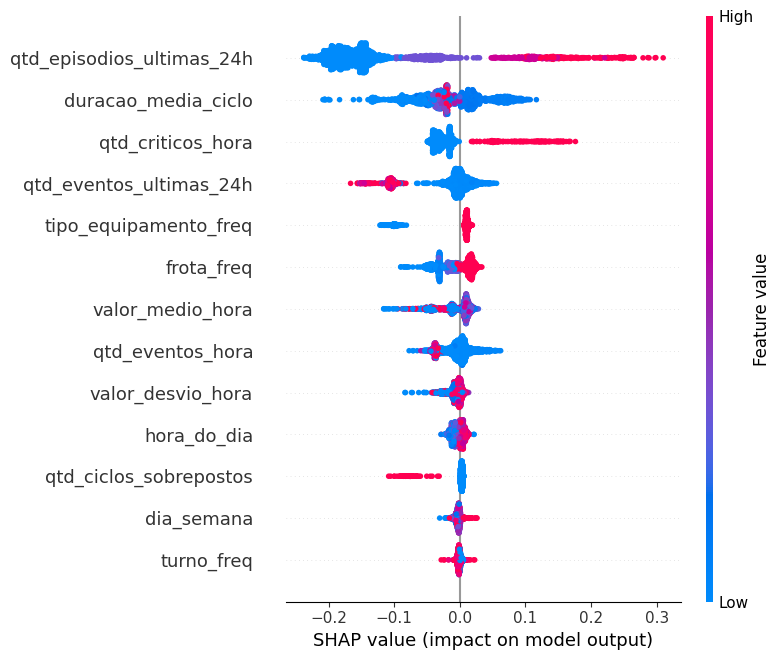

In [0]:
import shap

X_validacao_4h = pdf_validacao[colunas_features]
explainer = shap.TreeExplainer(modelos_rf[4])
amostra = X_validacao_4h.sample(min(2000, len(X_validacao_4h)), random_state=42)
shap_values = explainer.shap_values(amostra)

# Dependendo da versão do shap instalada, o retorno muda de formato — trato os dois casos
# pra não depender de saber de antemão qual versão está rodando no cluster.
if isinstance(shap_values, list):
    shap_values_classe_positiva = shap_values[1]
else:
    shap_values_classe_positiva = shap_values[:, :, 1]

shap.summary_plot(shap_values_classe_positiva, amostra, show=False)

**O que o SHAP me mostrou**

As duas features mais importantes fazem sentido operacional: `qtd_episodios_ultimas_24h` alta empurra a predição pra risco alto, e `qtd_criticos_hora` alta também — equipamento que já deu episódio recente ou tem leituras críticas na hora tem mais chance de dar risco de novo. Isso é um bom sinal de que o modelo aprendeu um padrão real, não ruído.

Uma feature me chamou atenção por ir na direção que eu não esperava: `qtd_eventos_ultimas_24h` alta está empurrando a predição pra risco **baixo**, e valores baixos empurram pra risco **alto** — o oposto da hipótese ingênua de que "mais eventos = mais risco".

Duas explicações que considero plausíveis, sem conseguir confirmar qual é a certa com os dados que tenho agora:
- Depois que apliquei o teto (winsorização) por causa do outlier do `PE3798`, uma contagem alta de eventos pode só significar "equipamento gerando bastante telemetria de rotina" (sensor verboso), não necessariamente um equipamento problemático — o modelo pode ter aprendido a não confundir volume de telemetria com risco.
- Pode ser um efeito mecânico inverso: depois de um episódio de risco, o equipamento às vezes é parado ou vai pra inspeção, o que **reduz** o volume de telemetria por um tempo — nesse caso, poucos eventos recentes seriam consequência de já estar sob atenção, não a causa do risco.

Não resolvo isso agora, mas deixo registrado como uma observação a investigar — é exatamente o tipo de feature "importante mas sem explicação operacional óbvia" que o Estudo Guiado pede pra sinalizar (CM 5.3), e viraria um bom ponto de partida pra um próximo ciclo de análise.

## 10. Matriz de confusão e comparação final

In [0]:
matriz_confusao_4h = confusion_matrix(resultados_rf[4]["y_validacao"], resultados_rf[4]["pred_ajustado"])
print("Matriz de confusão (Random Forest, janela 4h, limiar ajustado, validação):")
print(matriz_confusao_4h)
print(f"Falsos negativos (janela 4h, limiar ajustado): {matriz_confusao_4h[1][0]:,}")

print("\n=== Comparativo final (limiar ajustado pro Random Forest) ===")
print(f"{'Modelo':<32} {'Precision':>10} {'Recall':>10} {'F1':>10}")
for h in [4, 8]:
    p_base, r_base, f1_base = resultados_baseline[h]
    print(f"{'Baseline (' + str(h) + 'h)':<32} {p_base:>10.3f} {r_base:>10.3f} {f1_base:>10.3f}")
    print(f"{'Random Forest (' + str(h) + 'h, limiar 0.5)':<32} {resultados_rf[h]['precision_05']:>10.3f} "
          f"{resultados_rf[h]['recall_05']:>10.3f} {resultados_rf[h]['f1_05']:>10.3f}")
    print(f"{'Random Forest (' + str(h) + 'h, limiar ajustado)':<32} {resultados_rf[h]['precision_ajustado']:>10.3f} "
          f"{resultados_rf[h]['recall_ajustado']:>10.3f} {resultados_rf[h]['f1_ajustado']:>10.3f}")
print(f"{'Isolation Forest (top-10%, 4h)':<32} {'-':>10} {recall_top_k:>10.3f} {'-':>10}")

Matriz de confusão (Random Forest, janela 4h, limiar ajustado, validação):
[[10130  4667]
 [  345   805]]
Falsos negativos (janela 4h, limiar ajustado): 345

=== Comparativo final (limiar ajustado pro Random Forest) ===
Modelo                            Precision     Recall         F1
Baseline (4h)                         0.156      0.551      0.243
Random Forest (4h, limiar 0.5)        0.223      0.493      0.307
Random Forest (4h, limiar ajustado)      0.147      0.700      0.243
Baseline (8h)                         0.242      0.512      0.328
Random Forest (8h, limiar 0.5)        0.279      0.482      0.353
Random Forest (8h, limiar ajustado)      0.208      0.702      0.320
Isolation Forest (top-10%, 4h)            -      0.092          -


### 10.1 Onde o modelo mais erra — falsos negativos por equipamento e frota
A matriz de confusão me diz quantos falsos negativos existem, mas não onde. Preciso
saber se o modelo erra de forma espalhada (aceitável) ou se concentra os erros em
alguns equipamentos/frotas específicos (nesse caso, vale entender o porquê — pode ser
um padrão de falha que as features atuais não capturam bem).

In [0]:
import pandas as pd

# Recalculo as predições numa base que já carrega tag/frota/data_hora junto, pra poder
# cruzar erro com identificação do equipamento sem depender de reaproveitar índices de
# outra célula (mais seguro assim).
colunas_identificacao = ["tag", "frota", "data_hora"]
coluna_alvo_analise = "target_dont_go_proximas_4h"

df_validacao_analise = df_validacao.select(
    colunas_identificacao + colunas_features + [coluna_alvo_analise]
)
pdf_validacao_analise = (
    df_validacao_analise
    .na.drop(subset=colunas_features + [coluna_alvo_analise])
    .toPandas()
)

X_analise = pdf_validacao_analise[colunas_features]
y_analise = pdf_validacao_analise[coluna_alvo_analise]
proba_analise = modelos_rf[4].predict_proba(X_analise)[:, 1]
limiar_4h = limiares_escolhidos[4]
pred_analise = (proba_analise >= limiar_4h).astype(int)

pdf_validacao_analise["predicao"] = pred_analise
pdf_validacao_analise["falso_negativo"] = (y_analise == 1) & (pred_analise == 0)
pdf_validacao_analise["verdadeiro_positivo"] = (y_analise == 1) & (pred_analise == 1)

In [0]:
# Falsos negativos por equipamento — olho tanto o total quanto a TAXA (FN / total de
# positivos daquele equipamento), porque um equipamento com muitos positivos vai ter
# mais FN só por ter mais chances de errar, isso sozinho não quer dizer que o modelo
# é pior nele.
resumo_por_tag = (
    pdf_validacao_analise[pdf_validacao_analise[coluna_alvo_analise] == 1]
    .groupby("tag")
    .agg(
        qtd_positivos_reais=("falso_negativo", "size"),
        qtd_falsos_negativos=("falso_negativo", "sum"),
    )
)
resumo_por_tag["taxa_de_erro"] = resumo_por_tag["qtd_falsos_negativos"] / resumo_por_tag["qtd_positivos_reais"]
resumo_por_tag = resumo_por_tag.reset_index().sort_values("qtd_falsos_negativos", ascending=False)

print("Top 15 equipamentos com mais falsos negativos (em valor absoluto):")
display(resumo_por_tag.head(15))

print("\nTop 15 equipamentos com maior TAXA de falso negativo (mín. 5 positivos reais, pra não pegar ruído de amostra pequena):")
display(resumo_por_tag[resumo_por_tag["qtd_positivos_reais"] >= 5].sort_values("taxa_de_erro", ascending=False).head(15))

Top 15 equipamentos com mais falsos negativos (em valor absoluto):


tag,qtd_positivos_reais,qtd_falsos_negativos,taxa_de_erro
CA65921,55,38,0.6909090909090909
PE3797,34,34,1.0
CA65935,81,32,0.3950617283950617
CA65926,97,29,0.29896907216494845
CA65909,36,28,0.7777777777777778
CA65922,43,27,0.627906976744186
CA65928,39,20,0.5128205128205128
CA65931,71,19,0.2676056338028169
CA65936,74,13,0.17567567567567569
CA65792,80,13,0.1625



Top 15 equipamentos com maior TAXA de falso negativo (mín. 5 positivos reais, pra não pegar ruído de amostra pequena):


tag,qtd_positivos_reais,qtd_falsos_negativos,taxa_de_erro
CA65789,12,12,1.0
PE3797,34,34,1.0
CA65937,8,7,0.875
CA65909,36,28,0.7777777777777778
CA5926,16,12,0.75
CA65915,17,12,0.7058823529411765
CA65921,55,38,0.6909090909090909
CA65932,16,11,0.6875
CA65922,43,27,0.627906976744186
CA65928,39,20,0.5128205128205128


In [0]:
# Mesma lógica, agora por frota
resumo_por_frota = (
    pdf_validacao_analise[pdf_validacao_analise[coluna_alvo_analise] == 1]
    .groupby("frota")
    .agg(
        qtd_positivos_reais=("falso_negativo", "size"),
        qtd_falsos_negativos=("falso_negativo", "sum"),
    )
)
resumo_por_frota["taxa_de_erro"] = resumo_por_frota["qtd_falsos_negativos"] / resumo_por_frota["qtd_positivos_reais"]
resumo_por_frota = resumo_por_frota.reset_index().sort_values("taxa_de_erro", ascending=False)

print("Falsos negativos por frota:")
display(resumo_por_frota)

Falsos negativos por frota:


frota,qtd_positivos_reais,qtd_falsos_negativos,taxa_de_erro
letourneau l 1850,34,34,1.0
793-d 3s,36,28,0.7777777777777778
793-d 4s,285,114,0.4
793-d 2s,128,37,0.2890625
793-d 5s,667,132,0.19790104947526238


**Como eu leio esse resultado:** se a taxa de erro for parecida entre frotas/tags
(sem nenhuma muito destoante), o modelo está errando de forma consistente, o que é
mais fácil de justificar. Se uma frota ou um pequeno grupo de tags concentrar taxa de
erro bem mais alta que o resto, vale investigar se essas máquinas têm um padrão de
falha diferente (outro tipo de alarme, outro perfil de operação) que as features
atuais não capturam — e isso vira sugestão concreta de feature nova pro trabalho
futuro (CM 6.3), em vez de só uma limitação genérica.

**Confirmando com os nomes reais das frotas:** o modelo apresenta desempenho desigual entre frotas — a `letourneau l-1850`, que representa a frota com menor volume histórico de alertas na base (~150 registros contra milhares das frotas `793-d`), teve 100% de falsos negativos na validação — o modelo não conseguiu identificar nenhum dos 34 episódios de risco reais dessa frota. Já a frota `793-d 55`, com o maior volume de exemplos, teve a menor taxa de erro (20,2%). Isso indica que o desempenho do modelo está fortemente condicionado à quantidade de exemplos de treino disponíveis por frota, mais do que a uma limitação genérica do algoritmo.

Para mitigar o desempenho desigual entre frotas, proponho: (1) oversampling ou ponderação de classe específica por frota durante o treino, para compensar a escassez de exemplos das frotas minoritárias; (2) avaliar a viabilidade de um modelo dedicado ou regras específicas para a frota `letourneau l-1850`, dado seu perfil operacional distinto; (3) à medida que mais dados históricos dessa frota forem coletados, reavaliar se o desbalanceamento se mantém.

### 10.2 O modelo se mantém estável ao longo do tempo, ou piora (drift)?
Quebro o período de validação em semanas e olho se Precision/Recall se mantêm
estáveis ou vão caindo — isso indicaria que o padrão que o modelo aprendeu no treino
está ficando desatualizado (concept drift / data drift).

semana,precision,recall,qtd_positivos
2025-05-05/2025-05-11,0.20074349442379183,0.7941176470588235,340
2025-05-12/2025-05-18,0.1533879374534624,0.6798679867986799,303
2025-05-19/2025-05-25,0.1324110671936759,0.6907216494845361,291
2025-05-26/2025-06-01,0.09141274238227147,0.5561797752808989,178
2025-06-02/2025-06-08,0.15846994535519127,0.7631578947368421,38


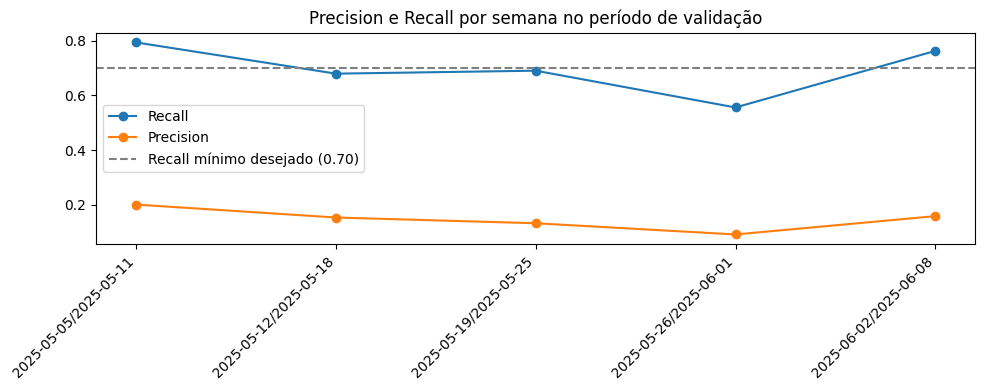

In [0]:
from sklearn.metrics import recall_score, precision_score
import matplotlib.pyplot as plt

pdf_validacao_analise["semana"] = pdf_validacao_analise["data_hora"].dt.to_period("W").astype(str)

resumo_semanal = []
for semana, grupo in pdf_validacao_analise.groupby("semana"):
    qtd_positivos_semana = grupo[coluna_alvo_analise].sum()
    if qtd_positivos_semana == 0:
        continue  # sem positivo na semana, Recall não é calculável
    resumo_semanal.append({
        "semana": semana,
        "precision": precision_score(grupo[coluna_alvo_analise], grupo["predicao"], zero_division=0),
        "recall": recall_score(grupo[coluna_alvo_analise], grupo["predicao"]),
        "qtd_positivos": int(qtd_positivos_semana),
    })

pdf_drift = pd.DataFrame(resumo_semanal).sort_values("semana")
display(pdf_drift)

plt.figure(figsize=(10, 4))
plt.plot(pdf_drift["semana"], pdf_drift["recall"], marker="o", label="Recall")
plt.plot(pdf_drift["semana"], pdf_drift["precision"], marker="o", label="Precision")
plt.axhline(y=RECALL_MINIMO_DESEJADO, color="gray", linestyle="--", label="Recall mínimo desejado (0.70)")
plt.title("Precision e Recall por semana no período de validação")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## 11. Gravando os resultados na Gold

In [0]:
pdf_validacao_resultado = pdf_validacao.copy()
pdf_validacao_resultado["proba_random_forest_4h"] = resultados_rf[4]["pred_proba"]
pdf_validacao_resultado["predicao_random_forest_4h"] = resultados_rf[4]["pred_ajustado"]
pdf_validacao_resultado["proba_random_forest_8h"] = resultados_rf[8]["pred_proba"]
pdf_validacao_resultado["predicao_random_forest_8h"] = resultados_rf[8]["pred_ajustado"]

df_resultado_gold = spark.createDataFrame(pdf_validacao_resultado)

(
    df_resultado_gold.write.format("delta").mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable("`estudo-guiado`.vale_gold.predicoes_risco_dont_go")
)

(
    df_features_gold.write.format("delta").mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable("`estudo-guiado`.vale_gold.features_tag_hora")
)

print("Gold gravada:")
print(" -> estudo-guiado.vale_gold.features_tag_hora")
print(" -> estudo-guiado.vale_gold.predicoes_risco_dont_go")

Gold gravada:
 -> estudo-guiado.vale_gold.features_tag_hora
 -> estudo-guiado.vale_gold.predicoes_risco_dont_go
